### "Boston Housing" dataset is taken from
https://www.kaggle.com/c/boston-housing


In [1]:
import os
import copy
import pickle
import sympy
import functools
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from error_injection import MissingValueError, SamplingError, Injector
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mutual_info_score, auc, roc_curve, roc_auc_score, f1_score
from scipy.optimize import minimize as scipy_min
from scipy.spatial import ConvexHull
from scipy.optimize import minimize, Bounds, linprog
from sympy import Symbol as sb
from sympy import lambdify
from tqdm.notebook import trange,tqdm
from IPython.display import display,clear_output
from random import choice
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
from queue import PriorityQueue
import time

class style():
    RED = '\033[31m'
    GREEN = '\033[32m'
    BLUE = '\033[34m'
    RESET = '\033[0m'

np.random.seed(1)

# ignore all the warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
boston_df = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [3]:
#MEDV is the median value. It is the target variable.
X = boston_df.drop(columns=['MEDV'])
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

#Expected 404, 13
#Expected 102, 13

Training data shape: (404, 13)
Testing data shape: (102, 13)


In [4]:
#LSTAT(Percentage of lower status of the population.) would have the highest negative correlation with MEDV.
def select_best_feature(X, y, method="correlation"):
    if method == "correlation":
        correlations = X.corrwith(y)
        best_feature = correlations.abs().idxmax()
    return best_feature

best_feature = select_best_feature(X_train, y_train)
best_feature

'LSTAT'

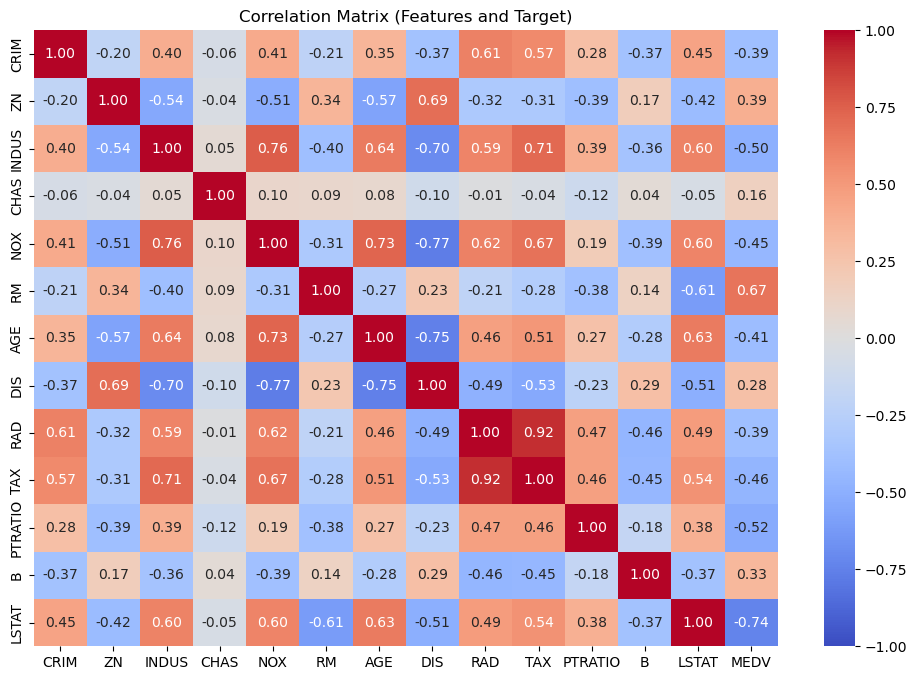

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = X_train.corr()

# Add the target variable to the matrix
correlation_matrix["MEDV"] = X_train.corrwith(y_train)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Features and Target)")
plt.show()


In [6]:
#Useful functions
symbol_id = -1
def create_symbol(suffix=''):
    global symbol_id
    symbol_id += 1
    name = f'e{symbol_id}_{suffix}' if suffix else f'e{symbol_id}'
    return sympy.Symbol(name=name)


scaler_symbols = set([sb(f'k{i}') for i in range(X_train.shape[1]+1)])
linearization_dict = dict()
reverse_linearization_dict = dict()

def inject_sensitive_ranges(X, y, uncertain_attr, uncertain_num, boundary_indices, uncertain_radius_pct=None, 
                  uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0]
    
    np.random.seed(seed)
    uncertain_indices = boundary_indices[:uncertain_num]
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    #print(uncertain_indices)
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, boundary_indices, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_sensitive_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, boundary_indices=boundary_indices, 
                                              uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

def inject_ranges(X, y, uncertain_attr, uncertain_num, uncertain_radius_pct=None, uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0]
    
    np.random.seed(seed)
    uncertain_indices = np.random.choice(range(len(y)), uncertain_num, replace=False)
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

In [7]:
#accuracy r2 = True; rmse, mse = False for maximize
def leave_one_out(X_train, y_train, X_test, y_test, model, metric, maximize=True): 
    predictions = model.fit(X_train, y_train).predict(X_test)
    initial_metric = metric(y_test.to_numpy(), predictions)
    influence_results = []
   
    for i in range(len(X_train)):
        X_train_new = np.delete(X_train, i, axis=0)
        y_train_new = np.delete(y_train, i, axis=0)
       
        model_clone = model.__class__(**model.get_params())
        new_preds = model_clone.fit(X_train_new, y_train_new).predict(X_test)
        new_metric = metric(y_test.to_numpy(), new_preds)
       
        metric_diff = (initial_metric - new_metric) if maximize else (new_metric - initial_metric)
        
        influence_results.append((i, metric_diff))
       
       
   
    influence_results = sorted(influence_results,key=lambda x: x[1], reverse=True)
    #print(influence_results)
    return [i[0] for i in influence_results]

def mae(y_true, y_pred):
    return sum(abs(y_true - y_pred))/len(y_true)

def mse(y_true, y_pred):
    return sum((y_true - y_pred)**2)/len(y_true)

def r_squared(y_true, y_pred):
    y_bar = np.mean(y_true)
    return 1 -(sum((y_true - y_pred)**2)/sum((y_true-y_bar)**2))

def rmse(y_true, y_pred):
    return np.sqrt(sum((y_true - y_pred)**2)/len(y_true))

In [8]:
lr = LinearRegression()
X_train, X_test, y_train, y_test = X_train.reset_index(drop=True) , X_test.reset_index(drop=True) , y_train.reset_index(drop=True) , y_test.reset_index(drop=True)
boundary_indices = leave_one_out(X_train, y_train, X_test, y_test, lr, mae, maximize=False)

In [9]:
# Decision Tree research: 1% of the data
array_indexes = np.zeros(len(X_train))
perc = 0.1 * len(X_train)
for i in range(0, len(X_train)):
    if i <= perc:
        index = boundary_indices[i]
        array_indexes[index] = 1

clf = DecisionTreeClassifier(max_depth=None)
clf.fit(X_train, array_indexes)

feature_max_values = X_train.max()



### My code diverges up to here

In [10]:
# Accessing the decision tree's internal structure
tree = clf.tree_

# Function to recursively extract the rules from the tree
def extract_rules(tree, feature_names, node=0, conditions=None):
    if conditions is None:
        conditions = {}

    # Get the feature and threshold for the current node
    feature = tree.feature[node]
    threshold = tree.threshold[node]
    
    # If it's a leaf node, return the rule at the current node
    if feature == _tree.TREE_UNDEFINED:
        return [(conditions, tree.value[node][0])]

    # Record the condition for this node
    feature_name = feature_names[feature] if feature != _tree.TREE_UNDEFINED else None
    conditions_copy = conditions.copy()

    if tree.children_left[node] != _tree.TREE_LEAF:
        conditions_copy[feature_name] = ("<= " + str(threshold))

    # Recurse down to the left and right child nodes
    left_rules = extract_rules(tree, feature_names, tree.children_left[node], conditions_copy)
    right_rules = extract_rules(tree, feature_names, tree.children_right[node], conditions_copy)

    return left_rules + right_rules

# Extracting the feature names from the training data
feature_names = X_train.columns

# Extract the rules from the tree
rules = extract_rules(tree, feature_names)

# Display the rules
for rule in rules:
    print("Rule: ", rule)



Rule:  ({'RM': '<= 7.627500057220459', 'B': '<= 354.1000061035156', 'LSTAT': '<= 12.130000114440918', 'INDUS': '<= 13.12000036239624'}, array([1., 0.]))
Rule:  ({'RM': '<= 7.627500057220459', 'B': '<= 354.1000061035156', 'LSTAT': '<= 12.130000114440918', 'INDUS': '<= 13.12000036239624', 'DIS': '<= 1.2713000178337097'}, array([1., 0.]))
Rule:  ({'RM': '<= 7.627500057220459', 'B': '<= 354.1000061035156', 'LSTAT': '<= 12.130000114440918', 'INDUS': '<= 13.12000036239624', 'DIS': '<= 1.2713000178337097'}, array([0., 1.]))
Rule:  ({'RM': '<= 6.172499895095825', 'B': '<= 16.220000505447388', 'LSTAT': '<= 12.130000114440918', 'TAX': '<= 688.5', 'NOX': '<= 0.6095000207424164'}, array([0., 1.]))
Rule:  ({'RM': '<= 5.875999927520752', 'B': '<= 351.51499938964844', 'LSTAT': '<= 12.130000114440918', 'TAX': '<= 688.5', 'NOX': '<= 0.6095000207424164', 'PTRATIO': '<= 16.249999523162842'}, array([0., 1.]))
Rule:  ({'RM': '<= 5.875999927520752', 'B': '<= 351.51499938964844', 'LSTAT': '<= 12.130000114440

### Anything after this is not touched yet.

In [41]:
def discretize_and_sample(X_train, feature, thresholds, total_samples, num_bins):
    feature_values = X_train[feature]  # Extract the column of interest
    min_val, max_val = feature_values.min(), feature_values.max()

    # Ensure the values are within the valid range of bins (clip out-of-range values)
    feature_values = feature_values.clip(lower=min_val, upper=max_val)

    # Dynamically calculate bin edges based on the feature values range
    bin_edges = np.linspace(min_val, max_val, num_bins + 1)
    bin_counts, bin_labels = pd.cut(feature_values, bins=bin_edges, labels=False, retbins=True)

    selected_bins_by_threshold = []  # Combined threshold list
    for thresh in thresholds:  # Iterate over age thresholds
        selected_bins = []  # New bin list for that respective threshold
        for bin_idx in range(num_bins):  # For each bin
            bin_lower = bin_edges[bin_idx]  # Get lower bin threshold at bin_idx
            bin_upper = bin_edges[bin_idx + 1]  # Get upper bin threshold at bin_idx
            if thresh[0] <= bin_lower and thresh[1] >= bin_upper:  # If bin meets threshold requirements
                selected_bins.append(bin_idx)
        selected_bins_by_threshold.append(selected_bins)  # Add threshold bin list to combined threshold list
    sampled_indices = set()

    for threshold_idx, selected_bins in enumerate(selected_bins_by_threshold):
        bin_freqs = feature_values.groupby(bin_counts).size()  # Calculate bin frequency of each bin for this threshold
        
        # Reindex to ensure all bins are accounted for, including those with zero frequency
        bin_freqs = bin_freqs.reindex(range(num_bins), fill_value=0)
        bin_priority = sorted([(bin_idx, bin_freqs[bin_idx])  # Sort by frequency of bin, decreasing
                           for bin_idx in selected_bins], 
                          key=lambda x: -x[1]) 
        
        for bin_idx, _ in bin_priority:  # Enumerate over the bins ordered by frequency for this threshold
            bin_indices = feature_values[bin_counts == bin_idx].index  # Get the indices
            needed = total_samples - len(sampled_indices)  # Get however many values are still needed to grab
            
            for idx in bin_indices:  # Iterate over indices
                if len(sampled_indices) < total_samples:
                    sampled_indices.add(idx)
                else:
                    break
            if len(sampled_indices) >= total_samples:
                break

        if len(sampled_indices) >= total_samples:  # End early if total samples needed is met
            break

    #print("Selected bins:", selected_bins_by_threshold)
    #print("Sampled indices:", sampled_indices)
            
    return list(sampled_indices), bin_edges

def heuristic_lattice_search(X_train, y_train, X_test, y_test, feature, thresholds, ratio, robustness_radius, uncertain_percentage):
    # Initialize parameters
    label_range = y_train.max() - y_train.min()
    uncertain_radius = ratio * label_range
    min_robustness_ratio = float('inf')
    best_bins = None
    best_result = None

    # Priority Queue for heuristic lattice search (score, num_bins, bin_edges)
    pq = PriorityQueue()

    # Initial coarse binning
    initial_num_bins = 5
    initial_sampled_indices, initial_bin_edges = discretize_and_sample(
        X_train, feature, thresholds,
        total_samples=int(uncertain_percentage * len(X_train)),
        num_bins=initial_num_bins
    )

    # Compute initial robustness ratio
    boundary_indices = np.array(initial_sampled_indices)
    initial_robustness_ratio = compute_robustness_ratio_sensitive_label_error(
        X_train, y_train, X_test, y_test,
        uncertain_num=int(uncertain_percentage * len(X_train)),
        boundary_indices=boundary_indices,
        uncertain_radius=uncertain_radius,
        robustness_radius=robustness_radius,
        interval=False
    )

    # Add initial configuration to priority queue
    pq.put((initial_robustness_ratio, initial_num_bins, initial_bin_edges))
    if initial_robustness_ratio < min_robustness_ratio:
        min_robustness_ratio = initial_robustness_ratio
        best_bins = initial_num_bins
        best_result = (initial_bin_edges, initial_robustness_ratio)

    print(initial_robustness_ratio)
    # Track progress with tqdm
    pbar = tqdm(total=1, desc="Lattice Search Progress", leave=True)  # Start with one element in the queue

    ratio_dct = {}
    
    # Lattice search
    while not pq.empty():
        current_score, num_bins, bin_edges = pq.get()
        pbar.update(1)  # Update progress for each configuration processed

        # Stop exploring if score exceeds the best robustness ratio
        #if current_score > min_robustness_ratio:
        #    continue

        # Try refining bins by increasing the number of bins in important ranges
        refined_bin_edges = np.linspace(bin_edges[0], bin_edges[-1], num_bins + 1)
        sampled_indices, refined_bin_edges = discretize_and_sample(
            X_train, feature, thresholds,
            total_samples=int(uncertain_percentage * len(X_train)),
            num_bins=num_bins + 1  # Refine by increasing bins
        )

        # Compute robustness ratio for refined bins
        boundary_indices = np.array(sampled_indices)
        refined_robustness_ratio = compute_robustness_ratio_sensitive_label_error(
            X_train, y_train, X_test, y_test,
            uncertain_num=int(uncertain_percentage * len(X_train)),
            boundary_indices=boundary_indices,
            uncertain_radius=uncertain_radius,
            robustness_radius=robustness_radius,
            interval=False
        )

        print(refined_robustness_ratio)
        if refined_robustness_ratio in ratio_dct and refined_robustness_ratio != 1:
            if ratio_dct[refined_robustness_ratio] > 2:
                break
            else:
               ratio_dct[refined_robustness_ratio] += 1
        else:
            ratio_dct[refined_robustness_ratio] = 1
        # Update best result if the refined ratio is better
        if refined_robustness_ratio < min_robustness_ratio:
            min_robustness_ratio = refined_robustness_ratio
            best_bins = num_bins + 1
            best_result = (refined_bin_edges, refined_robustness_ratio)

        # Add refined configuration back to the queue
        pq.put((refined_robustness_ratio, num_bins + 1, refined_bin_edges))
        pbar.total += 1  # Dynamically increase the progress bar's total size
        pbar.refresh()

    pbar.close()
    return best_bins, best_result

def find_best_bin_size(X_train, y_train, X_test, y_test, feature, thresholds, ratio, robustness_radius, uncertain_percentage):

    label_range = (y_train.max() - y_train.min())
    uncertain_radius = ratio * label_range
    min_robustness_ratio = float('inf')
    best_bins = None
    best_result = None
    
    # Wrapping the range with tqdm to display a progress bar
    #51
    for num_bins in tqdm(range(5, 51), desc='Testing bin sizes'):  # Progress bar with a description
        sampled_indices, bin_edges = discretize_and_sample(X_train, feature, thresholds, 
                                                           total_samples=int(uncertain_percentage * len(X_train)), 
                                                           num_bins=num_bins)
        
        boundary_indices = np.array(sampled_indices)
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(
            X_train, y_train, X_test, y_test,
            uncertain_num=int(uncertain_percentage * len(X_train)),
            boundary_indices=boundary_indices,
            uncertain_radius=uncertain_radius,
            robustness_radius=robustness_radius,
            interval=False
        )

        print(f"Bin number: {num_bins}, Robustness Ratio: {robustness_ratio}")
        
        if robustness_ratio < min_robustness_ratio:
            min_robustness_ratio = robustness_ratio
            best_bins = num_bins
            best_result = (bin_edges, robustness_ratio)
        elif robustness_ratio == min_robustness_ratio:
            if num_bins > best_bins:
                best_bins = num_bins
                best_result = (bin_edges, robustness_ratio)
    
    return best_bins, best_result

In [42]:
best_bins, best_result = find_best_bin_size(X_train, y_train, X_test, y_test, best_feature, thresholds, 0.25, 2, 0.1)

Testing bin sizes:   0%|          | 0/46 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
best_bins, best_result

(32,
 (array([ 1.73  ,  2.8625,  3.995 ,  5.1275,  6.26  ,  7.3925,  8.525 ,
          9.6575, 10.79  , 11.9225, 13.055 , 14.1875, 15.32  , 16.4525,
         17.585 , 18.7175, 19.85  , 20.9825, 22.115 , 23.2475, 24.38  ,
         25.5125, 26.645 , 27.7775, 28.91  , 30.0425, 31.175 , 32.3075,
         33.44  , 34.5725, 35.705 , 36.8375, 37.97  ]),
  0.19607843137254902))

In [12]:
boundary_indices, bin_edges = discretize_and_sample(X_train, best_feature, thresholds, total_samples=int(0.1 * len(X_train)), num_bins=best_bins)

In [13]:
# Testing more extreme uncertain percentages
robustness_dicts = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            #print(uncertain_radius)
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=boundary_indices,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts.append(robustness_dict)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [14]:
robustness_dicts_naive = []
for seed in tqdm(range(5), desc=f'Progress'):
    robustness_radius = 10
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc=f'Rep {seed+1}', leave=False):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
            robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts_naive.append(robustness_dict)

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Rep 1:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [15]:
# Testing more extreme uncertain percentages
robustness_dicts_interval = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=boundary_indices,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval.append(robustness_dict_interval)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [16]:
robustness_dicts_interval_naive = []
for seed in tqdm(range(5), desc=f'Progress'):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc=f'Rep {seed+1}', leave=False):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
            robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval_naive.append(robustness_dict_interval)

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Rep 1:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

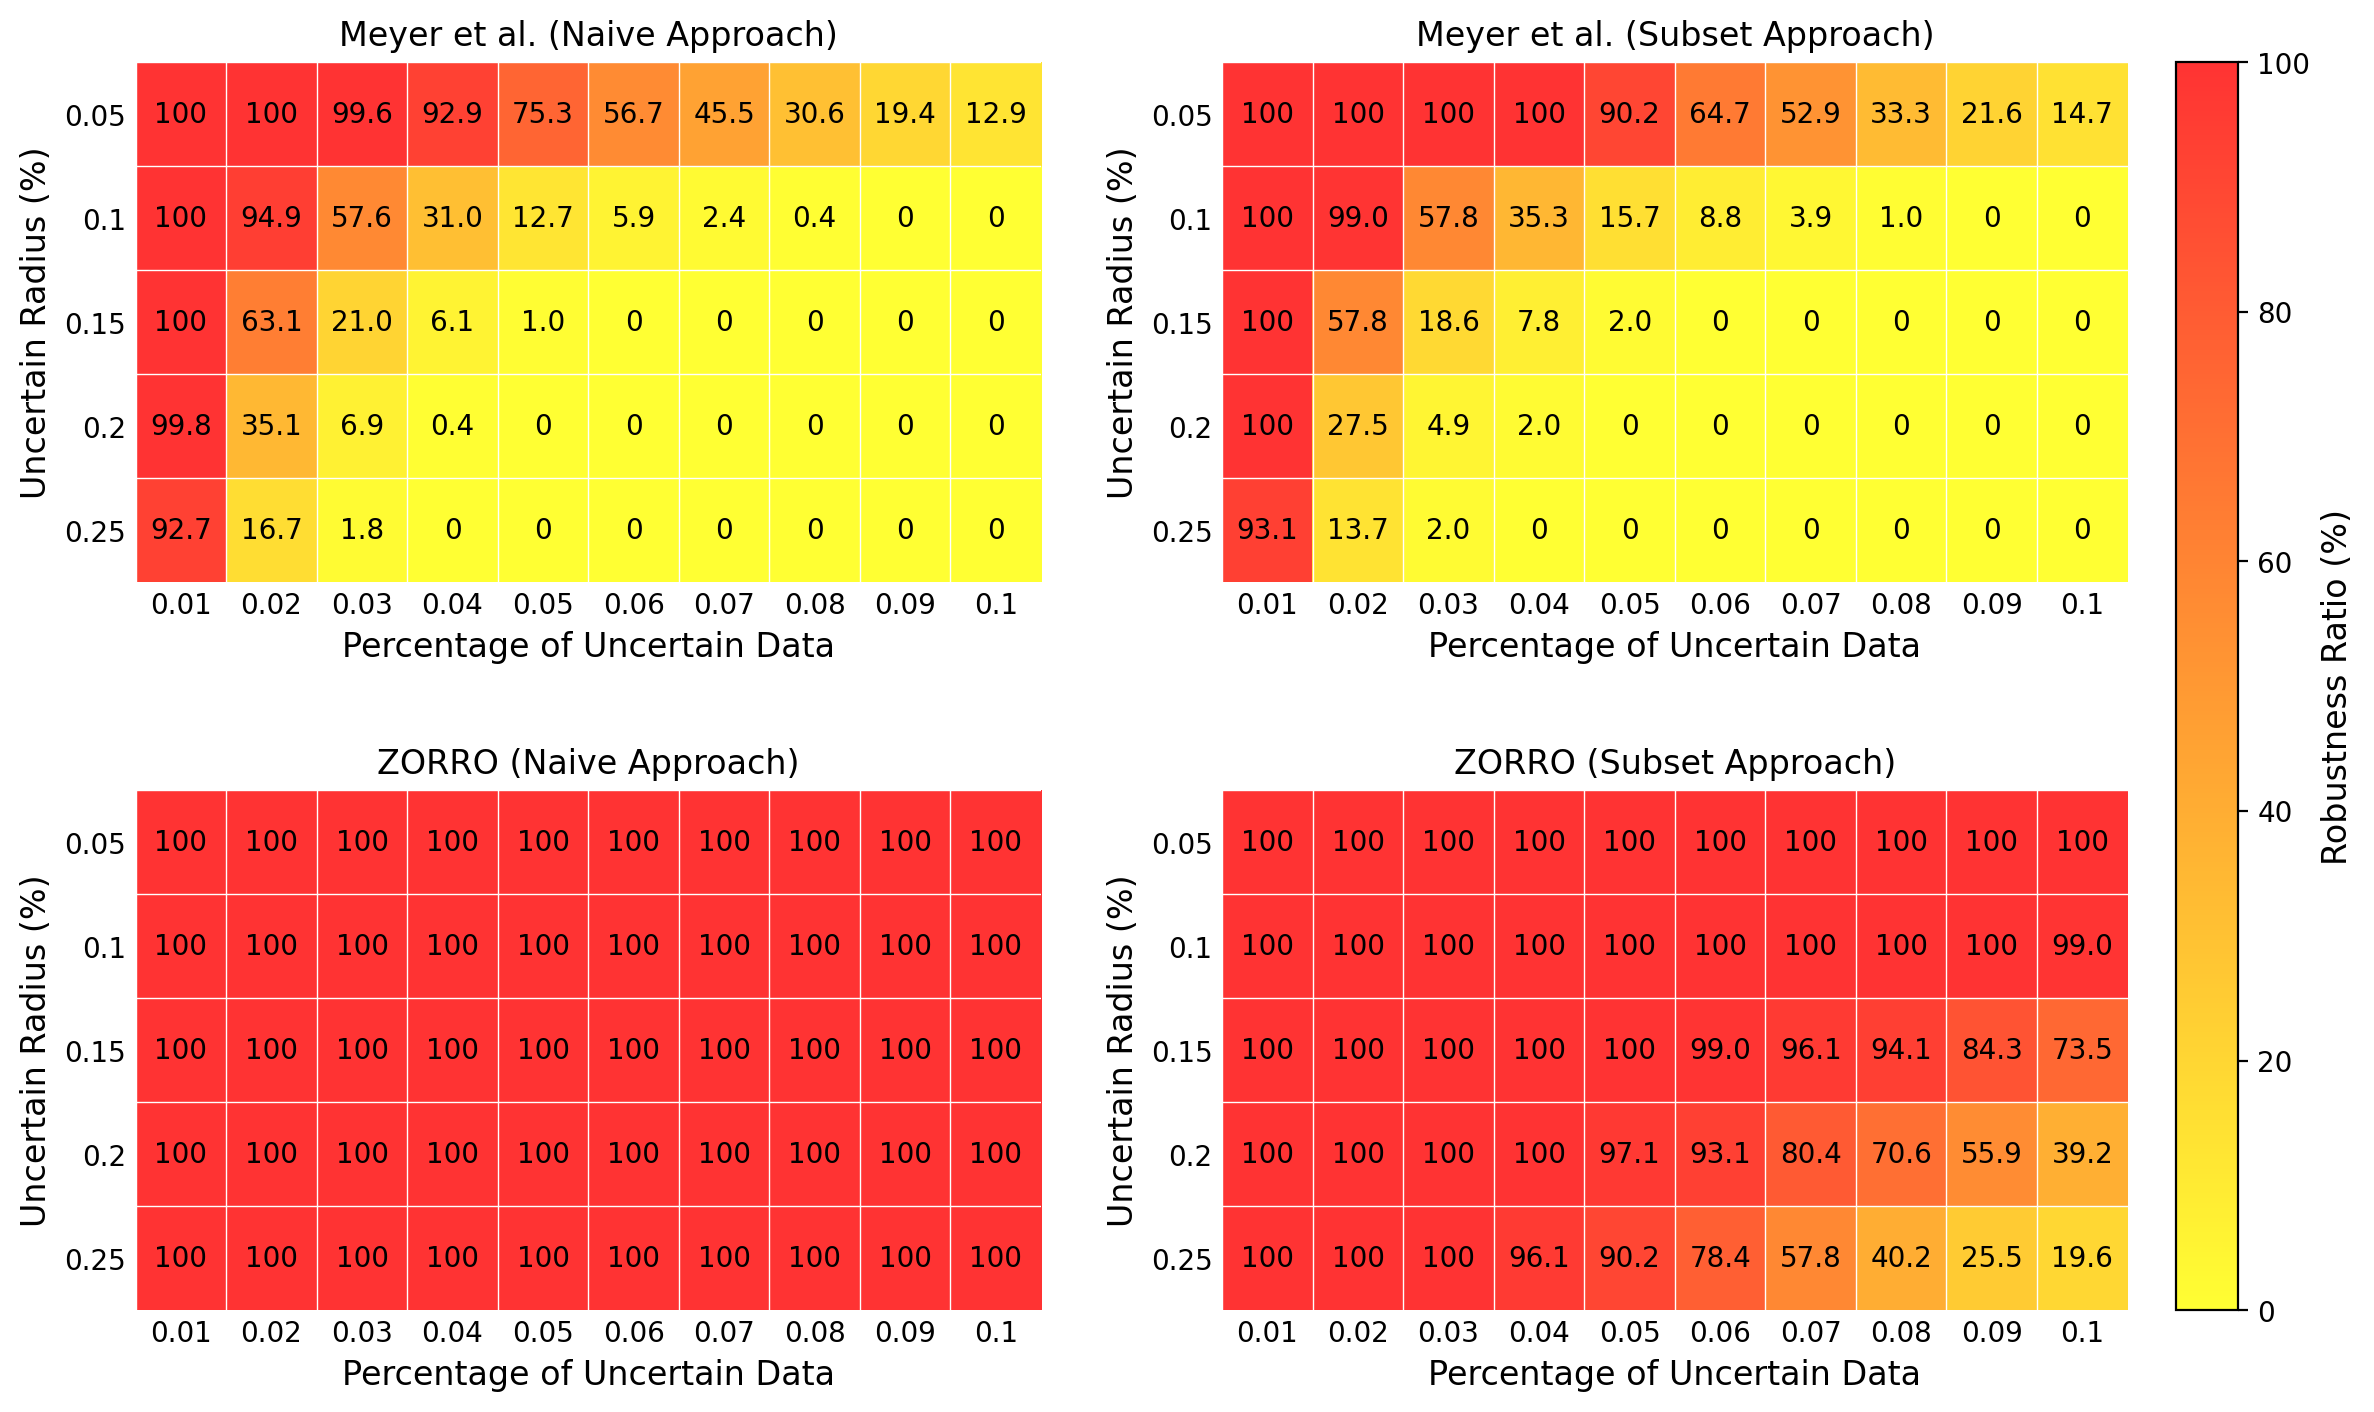

In [17]:
# Create the heatmap plot with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 8), dpi=200)

# Define colormap
cmap = plt.get_cmap("autumn_r")

# Function to plot a single heatmap
def plot_heatmap(ax, heatmap_data, x_labels, y_labels, title):
    heatmap = ax.imshow(heatmap_data, cmap=cmap, interpolation='nearest', 
                        aspect='auto', alpha=0.8, vmin=0, vmax=100)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.tick_params(axis='both', which='both', length=0)  # Remove tick marks
    
    # Add white lines by adjusting the linewidth for minor ticks
    ax.set_xticks(np.arange(len(x_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(y_labels)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Remove external boundaries
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add text annotations
    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            if heatmap_data[i][j] == 100:
                text = ax.text(j, i, '100', ha='center', va='center', color='black')
            elif heatmap_data[i][j] == 0:
                text = ax.text(j, i, '0', ha='center', va='center', color='black')
            else:
                text = ax.text(j, i, f'{heatmap_data[i][j]:.1f}', ha='center', va='center', color='black')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Percentage of Uncertain Data', fontsize=12)
    ax.set_ylabel('Uncertain Radius (%)', fontsize=12)

# Data for the heatmaps
df1 = sum([pd.DataFrame(robustness_dicts_interval_naive[i]).iloc[:, 2:] for i in range(5)])/5
df2 = sum([pd.DataFrame(robustness_dicts_interval[i]).iloc[:, 2:] for i in range(1)])/1
df3 = sum([pd.DataFrame(robustness_dicts_naive[i]).iloc[:, 2:] for i in range(5)])/5  
df4 = sum([pd.DataFrame(robustness_dicts[i]).iloc[:, 2:] for i in range(1)])/1  

# Convert fractions to percentages
heatmap_data1 = df1.multiply(100).values
heatmap_data2 = df2.multiply(100).values
heatmap_data3 = df3.multiply(100).values
heatmap_data4 = df4.multiply(100).values

# Labels
x_labels = df1.columns.tolist()
y_labels = [0.05, 0.10, 0.15, 0.2, 0.25]

# Plot each heatmap
plot_heatmap(axes[0, 0], heatmap_data1, x_labels, y_labels, 'Meyer et al. (Naive Approach)')
plot_heatmap(axes[0, 1], heatmap_data2, x_labels, y_labels, 'Meyer et al. (Subset Approach)')
plot_heatmap(axes[1, 0], heatmap_data3, x_labels, y_labels, 'ZORRO (Naive Approach)')
plot_heatmap(axes[1, 1], heatmap_data4, x_labels, y_labels, 'ZORRO (Subset Approach)')

# Adjust layout and add colorbar
plt.subplots_adjust(wspace=0.2, hspace=0.4, bottom=0.1, left=0.1, right=0.9)
cb = fig.colorbar(axes[0, 1].images[0], ax=axes, orientation='vertical', pad=0.02)
cb.set_label('Robustness Ratio (%)', fontsize=12)
plt.savefig('graph_outs/discretization_boston_linearReg_mae.pdf', bbox_inches='tight')

In [18]:
best_bins, best_result = heuristic_lattice_search(X_train, y_train, X_test, y_test, best_feature, thresholds, 0.25, 2, 0.1)

0.20588235294117646


Lattice Search Progress:   0%|          | 0/1 [00:00<?, ?it/s]

0.20588235294117646
0.19607843137254902
0.21568627450980393
0.22549019607843138
0.21568627450980393
0.22549019607843138
0.19607843137254902
0.21568627450980393
0.21568627450980393


In [19]:
best_bins, best_result

(7,
 (array([ 1.73      ,  6.90714286, 12.08428571, 17.26142857, 22.43857143,
         27.61571429, 32.79285714, 37.97      ]), 0.19607843137254902))

In [20]:
boundary_indices, bin_edges = discretize_and_sample(X_train, best_feature, thresholds, total_samples=int(0.1 * len(X_train)), num_bins=best_bins)

In [21]:
# Testing more extreme uncertain percentages
robustness_dicts_interval = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=boundary_indices,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval.append(robustness_dict_interval)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [22]:
# Testing more extreme uncertain percentages
robustness_dicts = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            #print(uncertain_radius)
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=boundary_indices,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts.append(robustness_dict)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

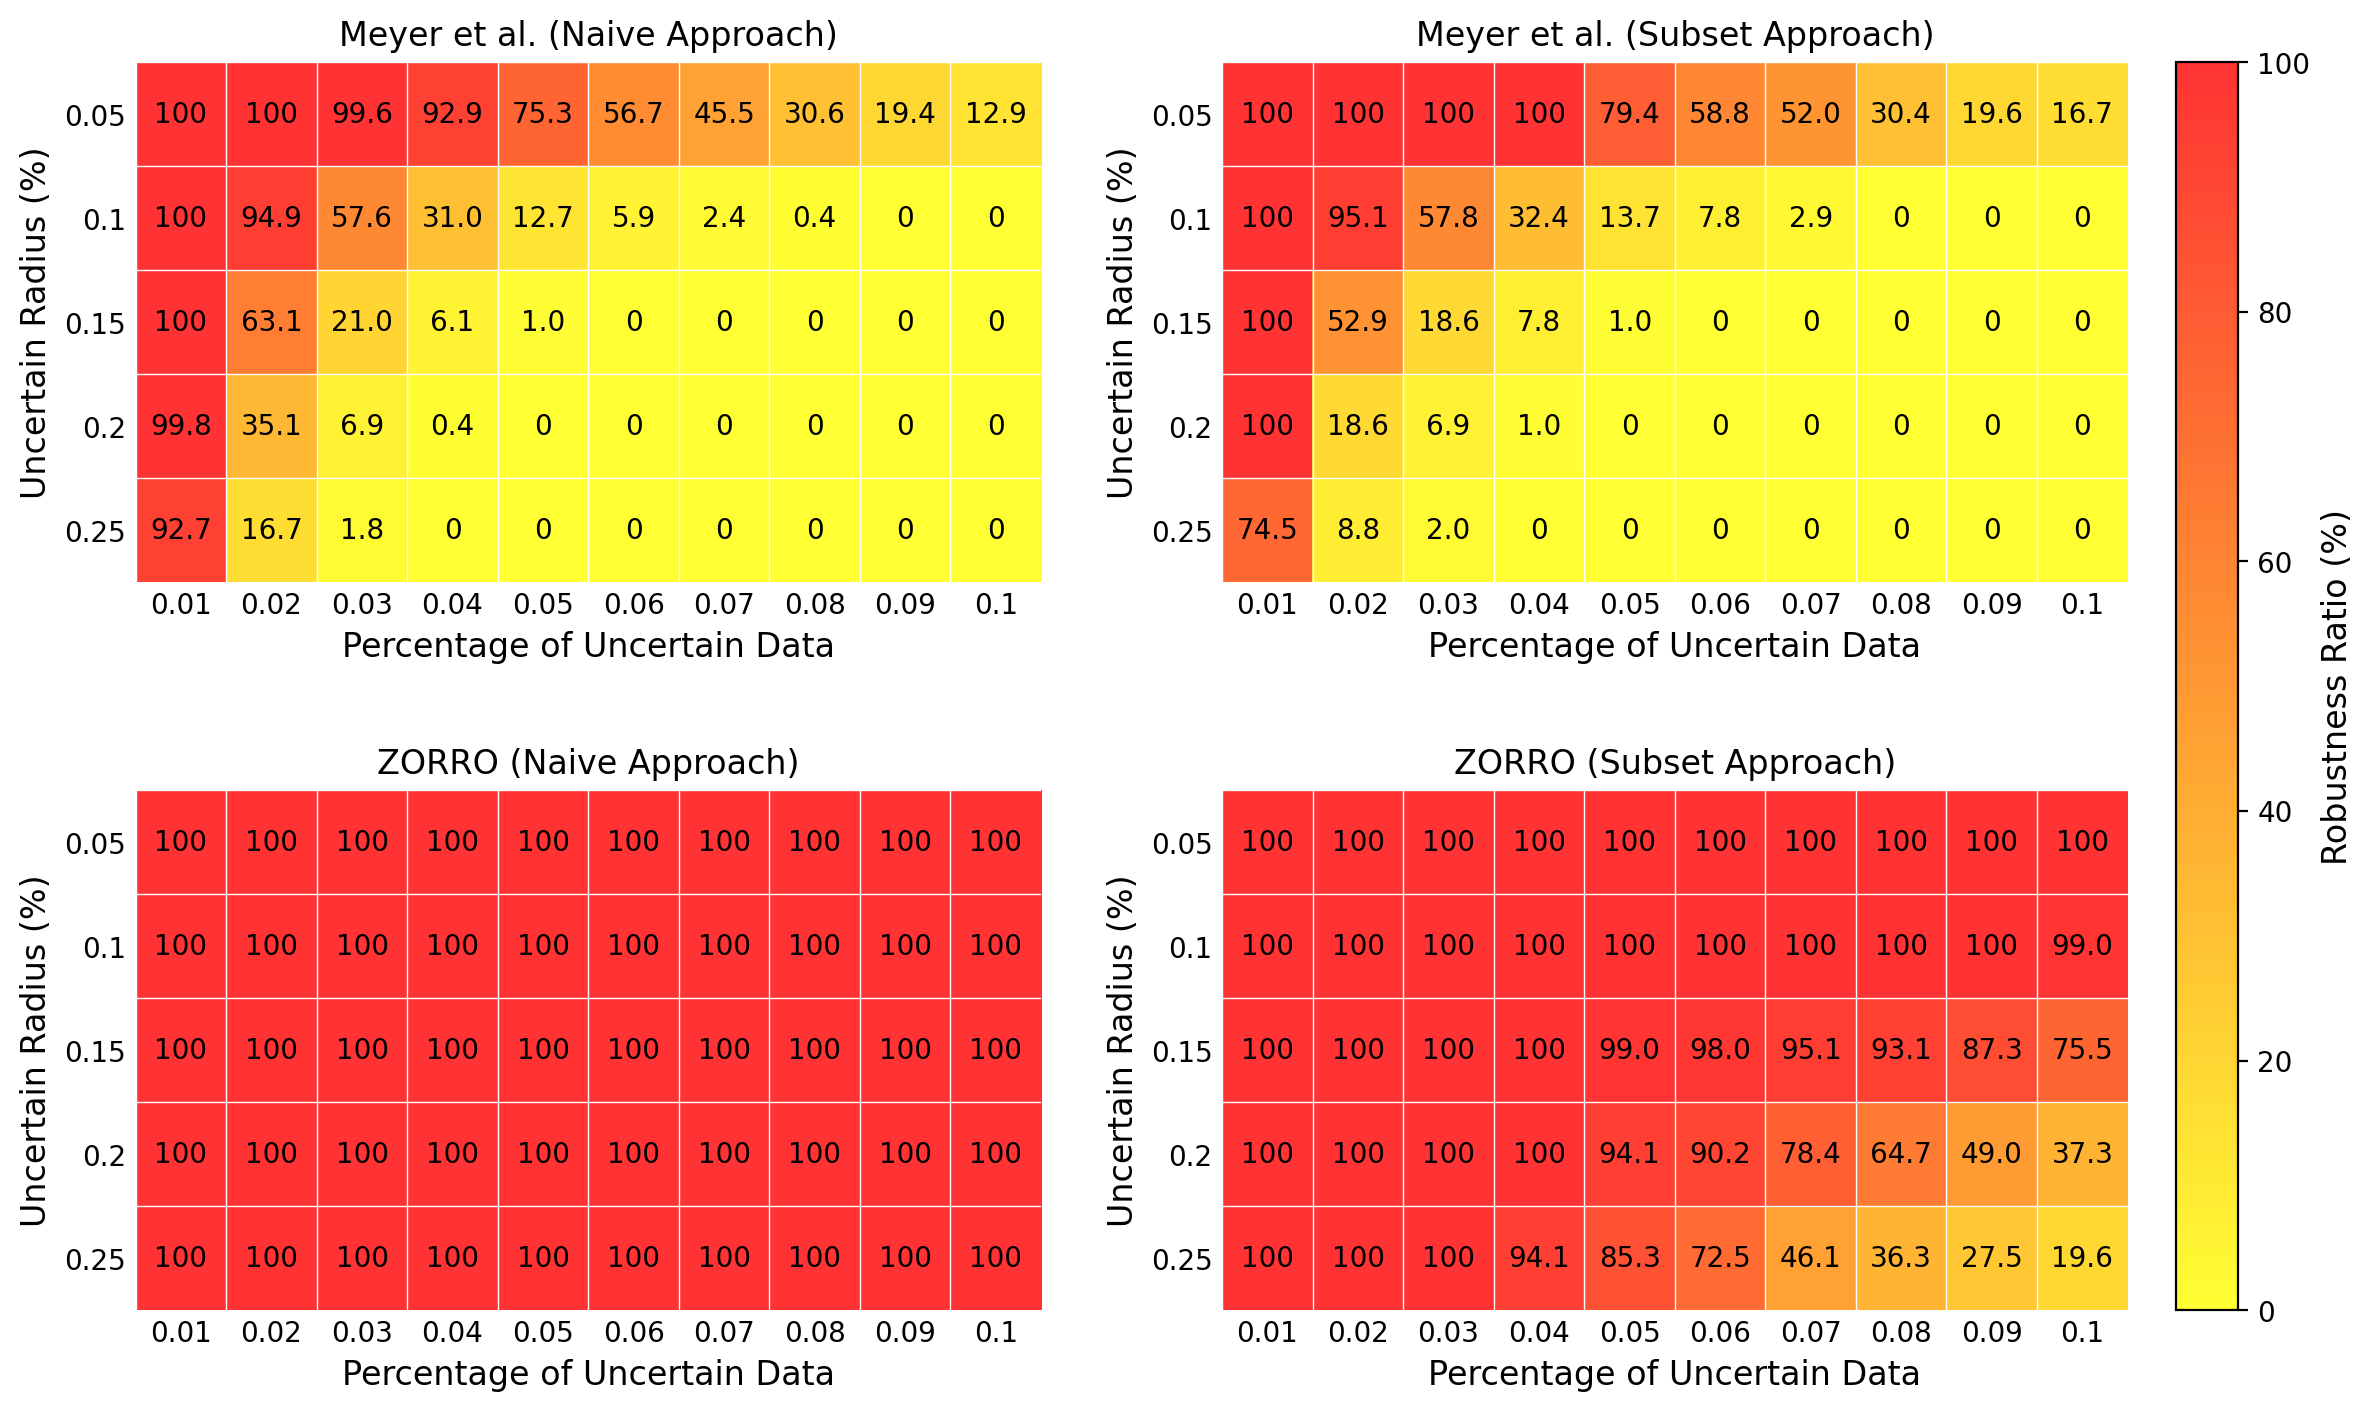

In [23]:
# Create the heatmap plot with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 8), dpi=200)

# Define colormap
cmap = plt.get_cmap("autumn_r")

# Function to plot a single heatmap
def plot_heatmap(ax, heatmap_data, x_labels, y_labels, title):
    heatmap = ax.imshow(heatmap_data, cmap=cmap, interpolation='nearest', 
                        aspect='auto', alpha=0.8, vmin=0, vmax=100)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.tick_params(axis='both', which='both', length=0)  # Remove tick marks
    
    # Add white lines by adjusting the linewidth for minor ticks
    ax.set_xticks(np.arange(len(x_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(y_labels)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Remove external boundaries
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add text annotations
    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            if heatmap_data[i][j] == 100:
                text = ax.text(j, i, '100', ha='center', va='center', color='black')
            elif heatmap_data[i][j] == 0:
                text = ax.text(j, i, '0', ha='center', va='center', color='black')
            else:
                text = ax.text(j, i, f'{heatmap_data[i][j]:.1f}', ha='center', va='center', color='black')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Percentage of Uncertain Data', fontsize=12)
    ax.set_ylabel('Uncertain Radius (%)', fontsize=12)

# Data for the heatmaps
df1 = sum([pd.DataFrame(robustness_dicts_interval_naive[i]).iloc[:, 2:] for i in range(5)])/5
df2 = sum([pd.DataFrame(robustness_dicts_interval[i]).iloc[:, 2:] for i in range(1)])/1
df3 = sum([pd.DataFrame(robustness_dicts_naive[i]).iloc[:, 2:] for i in range(5)])/5  
df4 = sum([pd.DataFrame(robustness_dicts[i]).iloc[:, 2:] for i in range(1)])/1  

# Convert fractions to percentages
heatmap_data1 = df1.multiply(100).values
heatmap_data2 = df2.multiply(100).values
heatmap_data3 = df3.multiply(100).values
heatmap_data4 = df4.multiply(100).values

# Labels
x_labels = df1.columns.tolist()
y_labels = [0.05, 0.10, 0.15, 0.2, 0.25]

# Plot each heatmap
plot_heatmap(axes[0, 0], heatmap_data1, x_labels, y_labels, 'Meyer et al. (Naive Approach)')
plot_heatmap(axes[0, 1], heatmap_data2, x_labels, y_labels, 'Meyer et al. (Subset Approach)')
plot_heatmap(axes[1, 0], heatmap_data3, x_labels, y_labels, 'ZORRO (Naive Approach)')
plot_heatmap(axes[1, 1], heatmap_data4, x_labels, y_labels, 'ZORRO (Subset Approach)')

# Adjust layout and add colorbar
plt.subplots_adjust(wspace=0.2, hspace=0.4, bottom=0.1, left=0.1, right=0.9)
cb = fig.colorbar(axes[0, 1].images[0], ax=axes, orientation='vertical', pad=0.02)
cb.set_label('Robustness Ratio (%)', fontsize=12)
plt.savefig('graph_outs/discretization_boston_linearReg_mae_heuristic.pdf', bbox_inches='tight')